# Immune Profiling of COVID-19 Severity: A Cross-Sectional Analysis

**Dataset**: Stephenson et al., Nature Medicine 2021 (E-MTAB-10026)

## Background

Stephenson et al. profiled peripheral blood mononuclear cells (PBMCs) from COVID-19 patients across severity groups and timepoints, providing insights into immune dynamics during disease progression.

### Important Methodological Notes

**This is an OBSERVATIONAL study, not a randomized trial:**
- Disease severity (Mild vs Severe) is an **outcome**, not a treatment assignment
- Patients are not randomly assigned to severity groups
- Differences between groups reflect disease biology, not causal treatment effects
- We use sctrial's infrastructure for structured comparisons, but interpret results as **descriptive associations**

**Time axis considerations:**
- **Days From Onset (DFO)**: Biological time since symptom onset - captures disease progression
- **Collection_Day**: Calendar time since study enrollment - captures sampling schedule
- These are fundamentally different; we use DFO for biological interpretability

**Analysis strategy:**
Given limited longitudinal pairing in this dataset, we focus on **cross-sectional comparisons** between severity groups at each timepoint, which is the most statistically appropriate approach.

## 1. Setup and Configuration

In [1]:
# Imports - consolidated in one cell
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu  # Import here for use across notebook
from pathlib import Path
import urllib.request

import sctrial as st

# Configuration constants
MIN_GENES_FOR_SCORE = 5
MIN_PARTICIPANTS_FOR_COMPARISON = 5
MIN_CELLS_PER_CELLTYPE = 100
SEED = 42

pd.options.mode.chained_assignment = None
print(f"sctrial version: {st.__version__ if hasattr(st, '__version__') else 'dev'}")

sctrial version: 0.2.1.dev1


## 2. Data Loading and Processing

In [2]:
# Helper functions for data loading
def _resolve_file(p: str) -> Path:
    path = Path(p)
    if path.is_absolute() and path.exists():
        return path
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / path
        if cand.exists():
            return cand
    return path


def _counts_like(X, sample: int = 10000, seed: int = 0) -> bool:
    """Check if matrix looks like raw counts."""
    if X is None:
        return False
    data = X.data if sp.issparse(X) else np.asarray(X).ravel()
    if data.size == 0:
        return False
    data = data[np.isfinite(data)]
    if data.size == 0 or data.min() < 0:
        return False
    rng = np.random.default_rng(seed)
    if data.size > sample:
        data = rng.choice(data, size=sample, replace=False)
    return np.allclose(data, np.round(data), atol=1e-3)


def _get_counts_matrix(adata):
    """Find raw counts in adata."""
    if "counts" in adata.layers and _counts_like(adata.layers["counts"]):
        return adata.layers["counts"], "layers['counts']"
    if getattr(adata, "raw", None) is not None:
        if list(adata.raw.var_names) == list(adata.var_names) and _counts_like(adata.raw.X):
            return adata.raw.X, "adata.raw.X"
    if "raw" in adata.layers and _counts_like(adata.layers["raw"]):
        return adata.layers["raw"], "layers['raw']"
    if _counts_like(adata.X):
        return adata.X, "adata.X"
    return None, None


def load_stephenson_data(
    data_path="data/stephenson/covid_portal_210320_with_raw.h5ad",
    processed_name="stephenson_covid19_v3.h5ad",
    seed=SEED,
    allow_download=False,
    force_reprocess=False,
):
    """Load and preprocess Stephenson COVID-19 dataset."""
    data_path = _resolve_file(data_path)
    data_root = data_path.parent.parent if data_path.exists() else Path("data")
    processed_path = data_root / "processed" / processed_name
    
    # Check for cached processed file
    if processed_path.exists() and not force_reprocess:
        adata = sc.read_h5ad(processed_path)
        print(f"Loaded cached file: {processed_path}")
        print(f"  {adata.n_obs:,} cells, {adata.n_vars:,} genes")
        return adata
    
    # Download if needed
    if not data_path.exists():
        if not allow_download:
            raise FileNotFoundError(
                f"Data not found at {data_path}. "
                "Download from: https://www.ebi.ac.uk/biostudies/files/E-MTAB-10026/"
            )
        url = "https://www.ebi.ac.uk/biostudies/files/E-MTAB-10026/covid_portal_210320_with_raw.h5ad"
        data_path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Downloading from {url}...")
        urllib.request.urlretrieve(url, data_path)
    
    print("Processing raw data...")
    adata = sc.read_h5ad(data_path)
    
    # Get counts
    X_counts, source = _get_counts_matrix(adata)
    if X_counts is None:
        raise ValueError("No raw counts found in dataset.")
    adata.layers["counts"] = X_counts
    print(f"  Counts source: {source}")
    
    # Process metadata
    obs = adata.obs.copy()
    
    # Severity groups
    obs["severity"] = obs["Status_on_day_collection_summary"].astype(str)
    obs = obs[obs["severity"].isin(["Mild", "Severe"])].copy()
    print(f"  After severity filter: {len(obs):,} cells")
    
    # Days from onset (DFO) - primary time axis
    obs["dfo"] = pd.to_numeric(obs["Days_from_onset"], errors="coerce")
    obs["dfo_bin"] = pd.cut(
        obs["dfo"],
        bins=[-np.inf, 7, 14, np.inf],
        labels=["DFO_0-7", "DFO_8-14", "DFO_15+"],
    ).astype(str)
    
    # Keep only valid DFO bins
    valid_dfo = obs["dfo_bin"].isin(["DFO_0-7", "DFO_8-14", "DFO_15+"])
    obs = obs[valid_dfo].copy()
    print(f"  After DFO filter: {len(obs):,} cells")
    
    # Collection day (for reference)
    if "Collection_Day" in obs.columns:
        obs["collection_day"] = obs["Collection_Day"].astype(str)
    
    # Standardize column names
    obs["participant_id"] = obs["patient_id"].astype(str)
    obs["celltype"] = obs["full_clustering"].astype(str)
    
    # Subset adata
    adata = adata[obs.index].copy()
    adata.obs = obs
    
    # Save processed
    processed_path.parent.mkdir(parents=True, exist_ok=True)
    adata.write_h5ad(processed_path)
    print(f"  Saved: {processed_path}")
    print(f"  Final: {adata.n_obs:,} cells, {adata.n_vars:,} genes")
    
    return adata

In [3]:
# Load data
adata = load_stephenson_data(force_reprocess=False)

print("\n=== Dataset Summary ===")
print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")
print(f"Severity groups: {adata.obs['severity'].unique().tolist()}")
print(f"DFO bins: {sorted(adata.obs['dfo_bin'].unique().tolist())}")
print(f"Cell types: {adata.obs['celltype'].nunique()}")
print(f"Participants: {adata.obs['participant_id'].nunique()}")

FileNotFoundError: Data not found at data/stephenson/covid_portal_210320_with_raw.h5ad. Download from: https://www.ebi.ac.uk/biostudies/files/E-MTAB-10026/

## 3. Sample Size Assessment

Before analysis, we assess sample sizes to determine appropriate statistical methods.

In [4]:
# Sample sizes by severity and timepoint
sample_sizes = (
    adata.obs
    .groupby(["severity", "dfo_bin"], observed=True)["participant_id"]
    .nunique()
    .unstack(fill_value=0)
)
print("Participants per severity × DFO bin:")
display(sample_sizes)

# Check for longitudinal pairing
def count_paired(obs, visit_col, visits):
    """Count participants with data at both visits."""
    wide = obs.pivot_table(
        index="participant_id", columns=visit_col, 
        aggfunc="size", fill_value=0, observed=True
    )
    has_both = (wide.get(visits[0], 0) > 0) & (wide.get(visits[1], 0) > 0)
    return has_both.sum()

dfo_visits = ["DFO_0-7", "DFO_8-14"]
n_paired_dfo = count_paired(adata.obs, "dfo_bin", dfo_visits)

print(f"\nLongitudinal pairing (DFO 0-7 → 8-14): {n_paired_dfo} participants")

if n_paired_dfo < MIN_PARTICIPANTS_FOR_COMPARISON:
    print(f"\n⚠️  WARNING: Only {n_paired_dfo} paired participants available.")
    print("   Difference-in-Differences analysis requires ≥4 paired participants.")
    print("   This notebook will focus on CROSS-SECTIONAL comparisons instead.")
    CAN_DO_DID = False
else:
    CAN_DO_DID = True

# Visualize sample sizes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Cells by severity
adata.obs["severity"].value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue", "coral"]
)
axes[0].set_title("Cells by Severity")
axes[0].set_ylabel("Number of cells")

# Cells by DFO
adata.obs["dfo_bin"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="teal"
)
axes[1].set_title("Cells by Days From Onset")

# Participants per group
sample_sizes.T.plot(kind="bar", ax=axes[2])
axes[2].set_title("Participants per Group")
axes[2].set_ylabel("Number of participants")
axes[2].legend(title="Severity")

plt.tight_layout()
plt.show()

NameError: name 'adata' is not defined

## 4. Study Design Configuration

We configure the comparison structure. Note: We use sctrial's `TrialDesign` for convenience, but this is an **observational** comparison, not a randomized trial.

In [5]:
# Add log1p-CPM normalization
if "log1p_cpm" not in adata.layers:
    adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")
    print("Added log1p_cpm layer")

# Define comparison design
# Note: We call Severe the "treated" group for sctrial compatibility,
# but this is purely for software purposes - there is no treatment!
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col="dfo_bin",
    arm_col="severity",
    arm_treated="Severe",   # Reference group for comparison
    arm_control="Mild",
    celltype_col="celltype",
)

# Available visits for analysis
available_visits = sorted(adata.obs["dfo_bin"].unique().tolist())
print(f"Available DFO bins: {available_visits}")

# Covariates - match actual column names in the dataset
covariate_mapping = {
    "Age_interval": "age",
    "Sex": "sex", 
    "Site": "site",
    "Smoker": "smoker",
}
covariates = [c for c in covariate_mapping.keys() if c in adata.obs.columns]
print(f"Available covariates: {covariates}")

# Check covariate distributions
if covariates:
    print("\nCovariate summary by severity:")
    for cov in covariates[:3]:  # Show first 3
        print(f"\n{cov}:")
        print(adata.obs.groupby("severity")[cov].value_counts().unstack(fill_value=0))

NameError: name 'adata' is not defined

## 5. Cell Type Quality Control

Filter to well-represented cell types for robust analysis.

In [6]:
# Cell type counts
ct_counts = adata.obs["celltype"].value_counts()
print(f"Total cell types: {len(ct_counts)}")

# Filter to well-represented types
valid_celltypes = ct_counts[ct_counts >= MIN_CELLS_PER_CELLTYPE].index.tolist()
print(f"Cell types with ≥{MIN_CELLS_PER_CELLTYPE} cells: {len(valid_celltypes)}")

# Show top cell types
print("\nTop 15 cell types:")
display(ct_counts.head(15).to_frame("n_cells"))

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
ct_counts.head(20).plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(MIN_CELLS_PER_CELLTYPE, color="red", linestyle="--", label=f"Min threshold ({MIN_CELLS_PER_CELLTYPE})")
ax.set_title("Cell Type Abundance")
ax.set_ylabel("Number of cells")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

NameError: name 'adata' is not defined

## 6. UMAP Visualization

In [7]:
# Compute UMAP if missing
if "X_umap" not in adata.obsm:
    print("Computing UMAP...")
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Global UMAP colored by cell type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color="celltype", ax=axes[0], show=False, 
           legend_loc="on data", legend_fontsize=6, title="Cell Types")
sc.pl.umap(adata, color="severity", ax=axes[1], show=False,
           palette=["steelblue", "coral"], title="Severity")

plt.tight_layout()
plt.show()

# UMAP by severity and DFO
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, severity in enumerate(["Mild", "Severe"]):
    for j, dfo in enumerate(["DFO_0-7", "DFO_8-14", "DFO_15+"]):
        ax = axes[i, j]
        mask = (adata.obs["severity"] == severity) & (adata.obs["dfo_bin"] == dfo)
        if mask.sum() > 0:
            sub = adata[mask].copy()
            sc.pl.umap(sub, color="celltype", ax=ax, show=False,
                      legend_loc="none", title=f"{severity} - {dfo} (n={mask.sum():,})")
        else:
            ax.set_title(f"{severity} - {dfo} (no cells)")
            ax.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'adata' is not defined

## 7. COVID-19 Immune Signatures

We define biologically relevant gene signatures for COVID-19 immune profiling, including:
- **Interferon response**: Key antiviral pathway, often elevated in severe disease
- **Inflammation**: S100 alarmins and cytokines associated with cytokine storm
- **Cytotoxicity**: NK/CD8 T cell function, important for viral clearance
- **T cell exhaustion**: Dysfunction markers elevated in severe/prolonged infection
- **Myeloid activation**: Monocyte/macrophage markers, drivers of pathology

In [8]:
available_genes = set(adata.var_names)

# COVID-19 relevant gene signatures
gene_signatures = {
    "IFN_Response": [
        "ISG15", "IFI6", "IFIT1", "IFIT2", "IFIT3", "MX1", "MX2", 
        "STAT1", "STAT2", "OAS1", "OAS2", "OAS3", "IRF7", "IFITM1", "IFITM3"
    ],
    "Inflammation": [
        "S100A8", "S100A9", "S100A12", "LYZ", "VCAN", "IL1B", 
        "CXCL8", "TNF", "NFKBIA", "CCL2", "CCL3", "CCL4"
    ],
    "Cytotoxicity": [
        "GZMB", "GZMA", "GZMH", "GZMK", "PRF1", "GNLY", "NKG7", 
        "KLRD1", "KLRB1", "IFNG"
    ],
    "T_Cell_Exhaustion": [
        "PDCD1", "LAG3", "HAVCR2", "TIGIT", "CTLA4", "TOX", "ENTPD1"
    ],
    "Myeloid_Activation": [
        "CD14", "FCGR3A", "CD68", "MARCO", "MSR1", "CD163", 
        "CTSS", "CST3", "LGALS3", "AIF1"
    ],
    "B_Cell_Activation": [
        "MS4A1", "CD19", "CD79A", "CD79B", "BANK1", "CD74", 
        "HLA-DRA", "HLA-DRB1", "IGHM", "IGHG1"
    ],
}

# Filter to available genes and report coverage
print("Gene signature coverage:")
print("-" * 50)
filtered_signatures = {}
for name, genes in gene_signatures.items():
    found = [g for g in genes if g in available_genes]
    pct = len(found) / len(genes) * 100
    print(f"{name}: {len(found)}/{len(genes)} genes ({pct:.0f}%)")
    if len(found) >= MIN_GENES_FOR_SCORE:
        filtered_signatures[name] = found
    else:
        print(f"  ⚠️  Skipping (need ≥{MIN_GENES_FOR_SCORE} genes)")

# Score gene sets using z-mean method (accounts for different expression scales)
if filtered_signatures:
    adata = st.score_gene_sets(
        adata, 
        filtered_signatures, 
        layer="log1p_cpm", 
        method="zmean",  # Z-score normalization for fair weighting
        prefix="sig_"
    )
    print(f"\n✓ Scored {len(filtered_signatures)} signatures")

# Get signature columns
signature_cols = [c for c in adata.obs.columns if c.startswith("sig_")]
print(f"\nSignature scores available: {signature_cols}")

NameError: name 'adata' is not defined

## 8. Cross-Sectional Comparisons: Severity Differences at Each Timepoint

This is the primary analysis. We compare immune signatures between Mild and Severe patients at each DFO timepoint, using:
- Participant-level aggregation (to avoid pseudoreplication)
- Cell-type adjustment (to account for compositional differences)
- FDR correction for multiple testing

In [9]:
# Run comparisons at each timepoint using sctrial's built-in function
# This properly aggregates to participant level and handles the statistics correctly
print("="*60)
print("CROSS-SECTIONAL ANALYSIS: Severe vs Mild at each DFO bin")
print("="*60)
print("\nPositive beta = higher in Severe; Negative beta = higher in Mild")
print("Using participant-level aggregation to avoid pseudoreplication\n")

all_results = []
for visit in available_visits:
    print(f"\n{visit}:")
    
    # Check sample size first
    ad_visit = adata[adata.obs["dfo_bin"] == visit]
    n_per_group = ad_visit.obs.groupby("severity")["participant_id"].nunique()
    
    if n_per_group.min() < MIN_PARTICIPANTS_FOR_COMPARISON:
        print(f"  Skipped: Insufficient participants (Mild={n_per_group.get('Mild', 0)}, Severe={n_per_group.get('Severe', 0)})")
        continue
    
    # Use sctrial's built-in between_arm_comparison
    # This properly aggregates to participant level
    res = st.between_arm_comparison(
        adata,
        visit=visit,
        features=signature_cols,
        design=design,
        aggregate="participant_visit",
        standardize=True,
        method="ols",
    )
    
    if not res.empty:
        # Rename columns for consistency
        res = res.rename(columns={"beta_arm": "beta", "p_arm": "p_value", "FDR_arm": "fdr"})
        res["timepoint"] = visit
        all_results.append(res)
        
        # Display results
        display_cols = ["feature", "beta", "p_value", "fdr", "n_units"]
        display(res[display_cols].round(4))
        
        # Highlight significant
        sig = res[res["fdr"] < 0.1]
        if not sig.empty:
            print(f"  Significant (FDR<0.1): {sig['feature'].tolist()}")

# Combine results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
else:
    combined_results = pd.DataFrame()

CROSS-SECTIONAL ANALYSIS: Severe vs Mild at each DFO bin

Positive beta = higher in Severe; Negative beta = higher in Mild
Using participant-level aggregation to avoid pseudoreplication



NameError: name 'available_visits' is not defined

## 9. Visualization of Severity Differences

NameError: name 'signature_cols' is not defined

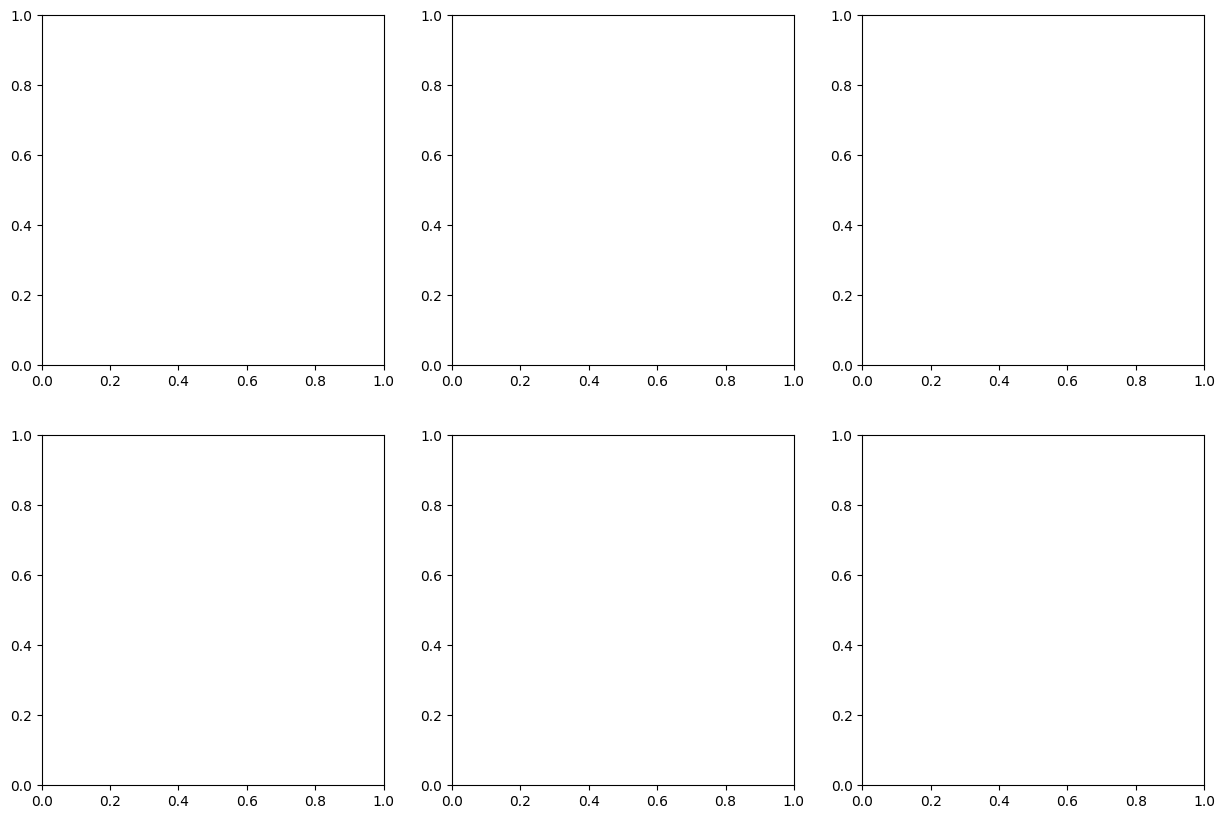

In [10]:
# Visualize signature distributions by severity and timepoint
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, sig in enumerate(signature_cols[:6]):
    ax = axes.flat[i]
    
    # Aggregate to participant level for cleaner visualization
    df_plot = (
        adata.obs
        .groupby(["participant_id", "severity", "dfo_bin"], observed=True)[sig]
        .mean()
        .reset_index()
    )
    
    sns.boxplot(
        data=df_plot, x="dfo_bin", y=sig, hue="severity",
        palette={"Mild": "steelblue", "Severe": "coral"},
        ax=ax
    )
    ax.set_title(sig.replace("sig_", ""))
    ax.set_xlabel("Days From Onset")
    ax.set_ylabel("Score (z-mean)")
    if i > 0:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

# Heatmap of effect sizes
if not combined_results.empty:
    pivot = combined_results.pivot(index="feature", columns="timepoint", values="beta")
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        pivot, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
        cbar_kws={"label": "Effect size (Severe - Mild)"}
    )
    plt.title("Severity Effect Sizes Across Timepoints")
    plt.tight_layout()
    plt.show()

## 10. Cell-Type Specific Analysis

Examine severity differences within specific immune cell populations.

In [11]:
# Focus on major immune populations
# Map fine cell types to major lineages for robust analysis
def categorize_celltype(ct):
    ct_lower = ct.lower()
    if "cd4" in ct_lower or "th1" in ct_lower or "th2" in ct_lower or "treg" in ct_lower:
        return "CD4_T"
    elif "cd8" in ct_lower or "cytotoxic" in ct_lower:
        return "CD8_T"
    elif "nk" in ct_lower or "natural killer" in ct_lower:
        return "NK"
    elif "b cell" in ct_lower or "plasma" in ct_lower or "b_cell" in ct_lower:
        return "B_cells"
    elif "mono" in ct_lower or "cd14" in ct_lower or "cd16" in ct_lower:
        return "Monocytes"
    elif "dc" in ct_lower or "dendritic" in ct_lower:
        return "DCs"
    else:
        return "Other"

adata.obs["lineage"] = adata.obs["celltype"].apply(categorize_celltype)
print("Lineage distribution:")
print(adata.obs["lineage"].value_counts())

# Compare signatures within key lineages
# IMPORTANT: We must aggregate to participant level to avoid pseudoreplication
focus_lineages = ["CD4_T", "CD8_T", "Monocytes", "NK"]
focus_visit = "DFO_0-7"  # Early disease

print(f"\n=== Cell-Type Specific Analysis at {focus_visit} ===")
print("Note: Using participant-level aggregation (not cell-level) for valid statistics\n")

lineage_results = []
for lineage in focus_lineages:
    ad_sub = adata[(adata.obs["lineage"] == lineage) & (adata.obs["dfo_bin"] == focus_visit)].copy()
    
    if ad_sub.n_obs < 100:
        print(f"{lineage}: Insufficient cells ({ad_sub.n_obs})")
        continue
    
    n_per_group = ad_sub.obs.groupby("severity")["participant_id"].nunique()
    if n_per_group.min() < 3:
        print(f"{lineage}: Insufficient participants")
        continue
    
    print(f"{lineage} (n={ad_sub.n_obs:,} cells, {n_per_group.sum()} participants):")
    
    # CORRECT: Aggregate to participant level FIRST, then test
    # This avoids pseudoreplication (treating each cell as independent)
    participant_means = (
        ad_sub.obs
        .groupby(["participant_id", "severity"], observed=True)[signature_cols[:4]]
        .mean()
        .reset_index()
    )
    
    for sig in signature_cols[:4]:
        mild_vals = participant_means.loc[participant_means["severity"] == "Mild", sig]
        severe_vals = participant_means.loc[participant_means["severity"] == "Severe", sig]
        
        # Now each value is one participant, not one cell
        stat, pval = mannwhitneyu(mild_vals, severe_vals, alternative="two-sided")
        
        diff = severe_vals.mean() - mild_vals.mean()
        lineage_results.append({
            "lineage": lineage,
            "signature": sig.replace("sig_", ""),
            "diff": diff,
            "p_value": pval,
            "n_mild": len(mild_vals),
            "n_severe": len(severe_vals),
        })

if lineage_results:
    df_lineage = pd.DataFrame(lineage_results)
    df_lineage["fdr"] = multipletests(df_lineage["p_value"], method="fdr_bh")[1]
    
    print("\nResults (participant-level Mann-Whitney U):")
    display(df_lineage.round(4))
    
    # Pivot for heatmap
    pivot = df_lineage.pivot(index="signature", columns="lineage", values="diff")
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, cmap="RdBu_r", center=0, annot=True, fmt=".2f")
    plt.title(f"Severity Differences by Cell Type ({focus_visit})\nPositive = higher in Severe")
    plt.tight_layout()
    plt.show()

NameError: name 'adata' is not defined

## 11. Cell Type Abundance Differences

Compare cell type composition between severity groups.

In [12]:
# Calculate cell type proportions per participant
# Note: Each row in 'props' after grouping is one participant-visit-lineage combination
# When we test, each participant contributes ONE proportion value per lineage
props = (
    adata.obs
    .groupby(["participant_id", "severity", "dfo_bin", "lineage"], observed=True)
    .size()
    .reset_index(name="n")
)
totals = props.groupby(["participant_id", "dfo_bin"])["n"].transform("sum")
props["proportion"] = props["n"] / totals

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By severity
props_by_sev = props.groupby(["severity", "lineage"])["proportion"].mean().unstack()
props_by_sev.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Cell Type Proportions by Severity")
axes[0].set_ylabel("Mean Proportion")
axes[0].legend(title="Lineage", bbox_to_anchor=(1.02, 1))

# Monocyte proportion over time
mono_props = props[props["lineage"] == "Monocytes"].copy()
sns.boxplot(data=mono_props, x="dfo_bin", y="proportion", hue="severity",
            palette={"Mild": "steelblue", "Severe": "coral"}, ax=axes[1])
axes[1].set_title("Monocyte Proportion by Severity and Time")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

# Statistical test for abundance differences
# CORRECT: Each observation in props_early is already at participant level
# so Mann-Whitney U is appropriate here (no pseudoreplication)
print("\nAbundance differences (Severe vs Mild) at DFO 0-7:")
print("Note: Each data point = one participant's cell type proportion")
print("-" * 50)

props_early = props[props["dfo_bin"] == "DFO_0-7"]
abundance_results = []
for lineage in ["Monocytes", "CD8_T", "NK", "B_cells"]:
    sub = props_early[props_early["lineage"] == lineage]
    mild = sub.loc[sub["severity"] == "Mild", "proportion"]
    severe = sub.loc[sub["severity"] == "Severe", "proportion"]
    
    if len(mild) >= 3 and len(severe) >= 3:
        stat, pval = mannwhitneyu(mild, severe, alternative="two-sided")
        diff = severe.mean() - mild.mean()
        abundance_results.append({
            "lineage": lineage,
            "diff": diff,
            "p_value": pval,
            "n_mild": len(mild),
            "n_severe": len(severe),
        })
        print(f"{lineage}: diff={diff:+.3f}, p={pval:.4f} (n_mild={len(mild)}, n_severe={len(severe)})")

if abundance_results:
    df_abund = pd.DataFrame(abundance_results)
    df_abund["fdr"] = multipletests(df_abund["p_value"], method="fdr_bh")[1]
    print(f"\nFDR-corrected results:")
    display(df_abund.round(4))

NameError: name 'adata' is not defined

## 12. Individual Gene Analysis

Examine specific genes of interest for COVID-19.

In [13]:
# Key COVID-19 genes
covid_genes = [
    "ISG15", "IFIT1", "MX1",       # IFN response
    "S100A8", "S100A9", "S100A12",  # Alarmins
    "GZMB", "PRF1", "NKG7",         # Cytotoxicity  
    "IL1B", "TNF", "CXCL8",         # Cytokines
]
covid_genes = [g for g in covid_genes if g in adata.var_names]
print(f"Analyzing {len(covid_genes)} COVID-relevant genes")

# Extract expression for visualization
gene_expr = pd.DataFrame(
    adata[:, covid_genes].layers["log1p_cpm"].toarray() if sp.issparse(adata[:, covid_genes].layers["log1p_cpm"]) 
    else adata[:, covid_genes].layers["log1p_cpm"],
    columns=covid_genes,
    index=adata.obs_names
)
gene_expr = gene_expr.join(adata.obs[["severity", "dfo_bin", "participant_id", "lineage"]])

# Aggregate to participant level
gene_means = gene_expr.groupby(["participant_id", "severity", "dfo_bin"])[covid_genes].mean().reset_index()

# Visualize key genes
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, gene in enumerate(covid_genes[:6]):
    ax = axes.flat[i]
    sns.boxplot(
        data=gene_means, x="dfo_bin", y=gene, hue="severity",
        palette={"Mild": "steelblue", "Severe": "coral"}, ax=ax
    )
    ax.set_title(gene)
    ax.set_xlabel("")
    if i > 0:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

# Dotplot of genes by cell type
if len(covid_genes) > 0:
    sc.pl.dotplot(
        adata[adata.obs["lineage"].isin(["Monocytes", "CD8_T", "NK", "CD4_T"])],
        var_names=covid_genes[:8],
        groupby="lineage",
        standard_scale="var",
        title="COVID-19 Genes by Cell Type"
    )

NameError: name 'adata' is not defined

## 13. Summary and Conclusions

In [14]:
print("="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print(f"""
Dataset: Stephenson et al. COVID-19 PBMC
  - Total cells: {adata.n_obs:,}
  - Participants: {adata.obs['participant_id'].nunique()}
  - Severity groups: Mild vs Severe
  - Time axis: Days from symptom onset (DFO)

Analysis approach:
  - Cross-sectional comparisons (observational, not causal)
  - Participant-level aggregation to avoid pseudoreplication
  - Cell-type adjustment for compositional differences
  - FDR correction for multiple testing

Key limitations:
  - Observational data: severity is an outcome, not treatment
  - Limited longitudinal pairing: {n_paired_dfo} participants with repeat samples
  - Cannot establish causality between immune profiles and severity
  - Confounding by disease duration, treatment, comorbidities

Interpretation:
  - Positive effects indicate HIGHER values in Severe vs Mild
  - These are associations, not causal effects
  - Results describe immune differences between severity groups
""")

# Summary of significant findings
if not combined_results.empty:
    sig_results = combined_results[combined_results["fdr"] < 0.1]
    if not sig_results.empty:
        print("\nSignificant associations (FDR < 0.1):")
        print("-" * 50)
        for _, row in sig_results.iterrows():
            direction = "↑ Severe" if row["beta"] > 0 else "↑ Mild"
            print(f"  {row['feature']} at {row['timepoint']}: {direction} (β={row['beta']:.2f}, FDR={row['fdr']:.3f})")
    else:
        print("\nNo signatures reached FDR < 0.1 significance.")
        print("This may reflect:")
        print("  - True lack of differences")
        print("  - Insufficient sample size")
        print("  - High heterogeneity within groups")

ANALYSIS SUMMARY


NameError: name 'adata' is not defined

## 14. Longitudinal Analysis (If Sufficient Pairing)

DiD analysis requires repeated measurements from the same participants. We check if this is feasible.

In [15]:
if CAN_DO_DID:
    print("Running Difference-in-Differences analysis...")
    
    visits_for_did = ("DFO_0-7", "DFO_8-14")
    
    did_results = st.did_table(
        adata,
        features=signature_cols,
        design=design,
        visits=visits_for_did,
        aggregate="participant_visit",
        standardize=True,
        use_bootstrap=True,
        n_boot=199,
    )
    
    if not did_results.empty:
        print("\nDiD Results (change over time differs by severity):")
        display(did_results[["feature", "beta_DiD", "se_DiD", "p_DiD", "FDR_DiD"]].round(4))
        
        # Forest plot
        fig, ax = plt.subplots(figsize=(8, 5))
        st.plot_did_forest(did_results, ax=ax, title="DiD Effect Sizes")
        plt.tight_layout()
        plt.show()
else:
    print(f"""
╔══════════════════════════════════════════════════════════════╗
║  LONGITUDINAL ANALYSIS NOT PERFORMED                         ║
╠══════════════════════════════════════════════════════════════╣
║  Reason: Only {n_paired_dfo} participants have paired samples           ║
║  Required: ≥4 participants with data at both timepoints      ║
║                                                              ║
║  This is a limitation of the dataset, not the method.        ║
║  The cross-sectional analyses above remain valid.            ║
╚══════════════════════════════════════════════════════════════╝
""")

NameError: name 'CAN_DO_DID' is not defined